In [1]:
%pip install numpy opencv-python matplotlib scikit-learn

  Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_11_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_11_0_arm64.whl (54.8 MB)
Note: you may need to restart the kernel to use updated packages.


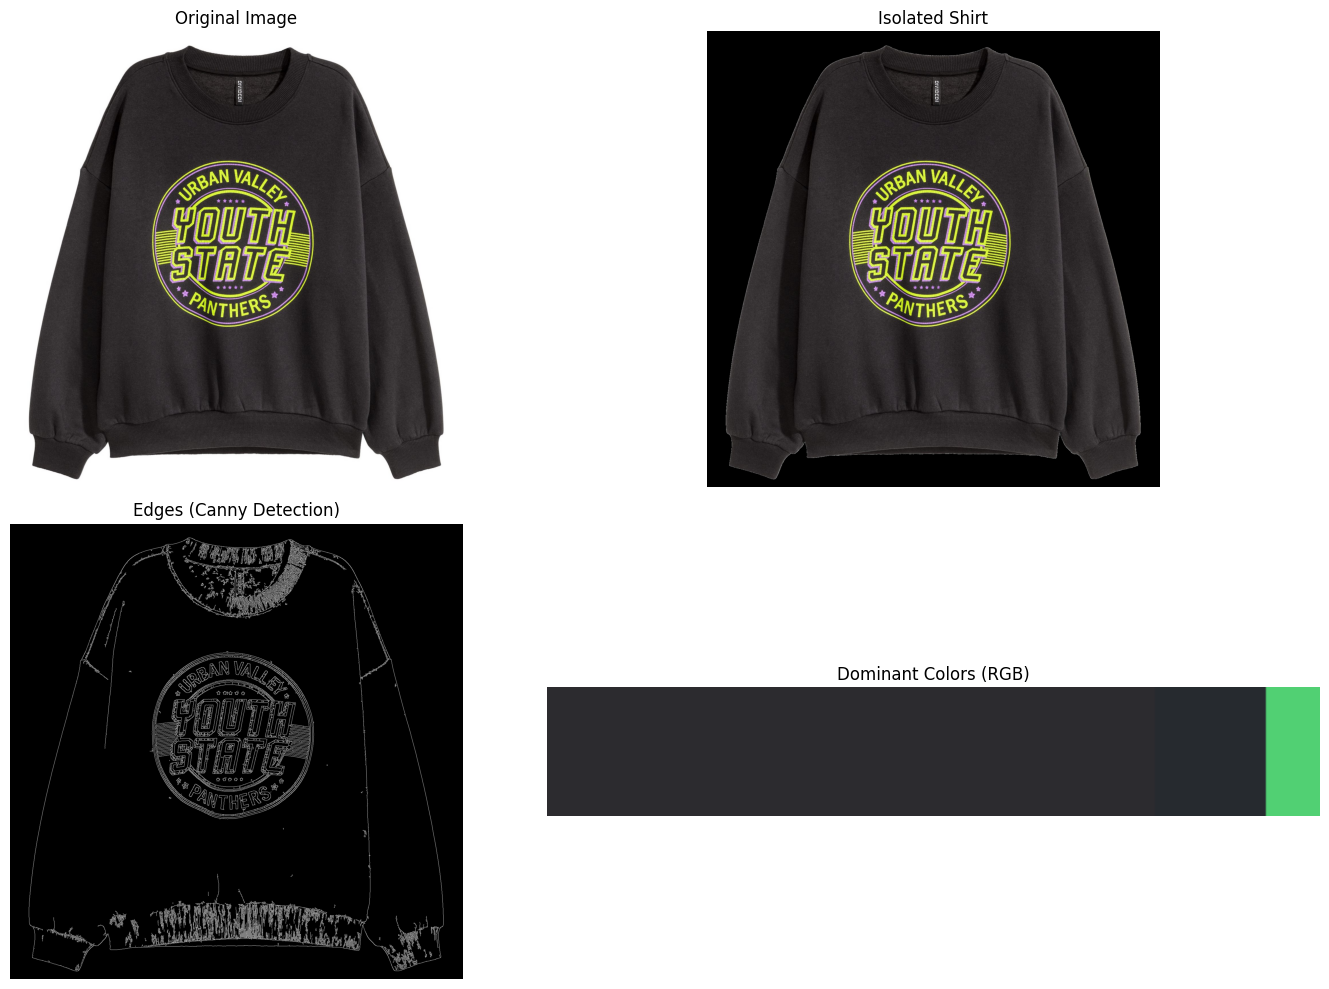

Dominant Colors (RGB): [array([47, 43, 44], dtype=uint8), array([47, 42, 38], dtype=uint8), array([115, 208,  81], dtype=uint8)]
Proportions: [0.78876422 0.14450478 0.066731  ]


In [1]:
# Import necessary libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

# Function to visualize dominant colors
def visualize_dominant_colors(colors, proportions):
    """
    Visualize the dominant colors as a horizontal bar chart.
    """
    bar_height = 50
    bar = np.zeros((bar_height, 300, 3), dtype=np.uint8)
    start_x = 0

    for i, (color, proportion) in enumerate(zip(colors, proportions)):
        end_x = start_x + int(proportion * 300)
        cv2.rectangle(bar, (start_x, 0), (end_x, bar_height),
                      tuple(map(int, color[::-1])), -1)  # Convert from RGB to BGR
        start_x = end_x

    return bar

# Main function to extract and visualize dominant colors
def process_image(image_path):
    # Step 1: Load the image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Step 2: Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 3: Apply Canny edge detection
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    # Step 4: Find contours and isolate the largest one (short-sleeve region)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [contour], -1, (255), thickness=cv2.FILLED)

    # Step 5: Apply the mask to the original image
    isolated_shirt = cv2.bitwise_and(image, image, mask=mask)

    # Step 6: Extract dominant colors
    hsv_image = cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2HSV)
    non_black_mask = cv2.inRange(isolated_shirt, (1, 1, 1), (255, 255, 255))
    isolated_pixels = hsv_image[non_black_mask > 0]

    # Use KMeans to cluster colors
    kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust n_clusters as needed
    kmeans.fit(isolated_pixels)
    dominant_colors = kmeans.cluster_centers_[:, :3]  # HSV values
    proportions = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    # Convert dominant colors to RGB for visualization
    dominant_colors_rgb = [cv2.cvtColor(np.uint8([[color]]), cv2.COLOR_HSV2RGB)[0][0]
                           for color in dominant_colors]

    # Visualize results
    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    # Isolated shirt
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.title("Isolated Shirt")
    plt.axis("off")

    # Edges
    plt.subplot(2, 2, 3)
    plt.imshow(edges, cmap="gray")
    plt.title("Edges (Canny Detection)")
    plt.axis("off")

    # Dominant colors
    bar = visualize_dominant_colors(dominant_colors_rgb, proportions)
    plt.subplot(2, 2, 4)
    plt.imshow(bar)
    plt.title("Dominant Colors (RGB)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Print dominant colors and proportions
    print("Dominant Colors (RGB):", dominant_colors_rgb)
    print("Proportions:", proportions)

# Call the function with your local image path
# Replace 'image_path' with the actual image path on your local system
process_image("/Users/Tommy/Downloads/WhatsApp Image 2024-11-07 at 01.02.41.jpeg")


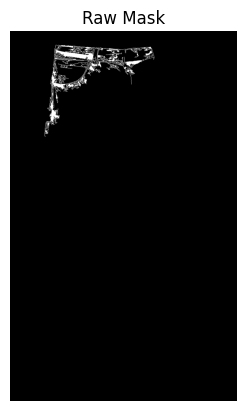

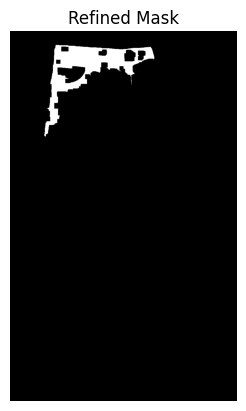

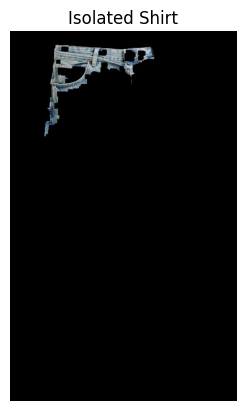

Number of isolated pixels: 1165788
Dominant Colors (RGB): [array([0, 0, 0], dtype=uint8), array([142, 161, 162], dtype=uint8), array([57, 83, 96], dtype=uint8)]
Proportions: [0.97099816 0.02160856 0.00739328]


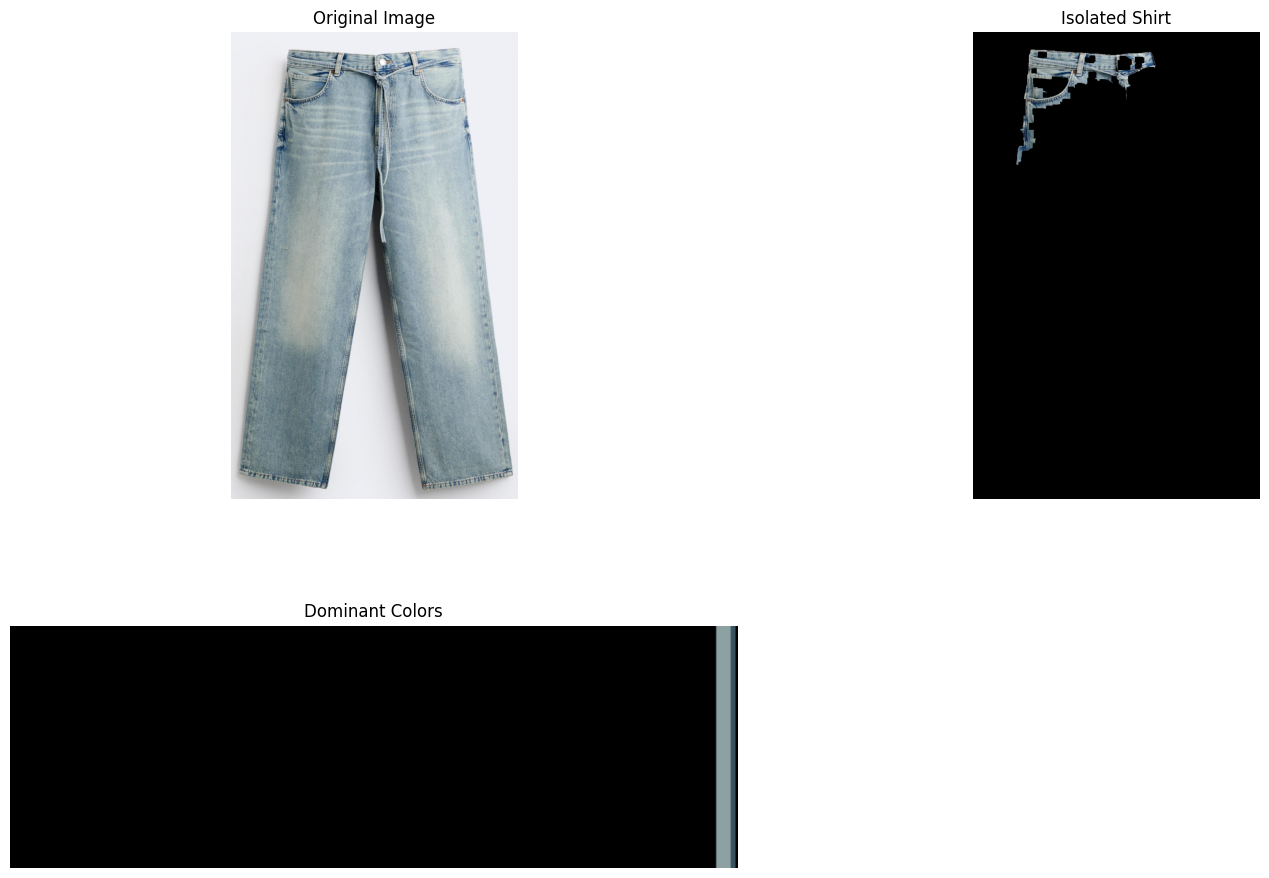

In [13]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def visualize_dominant_colors(colors, proportions):
    """
    Generate a bar chart showing the proportions of dominant colors.
    """
    bar = np.zeros((100, 300, 3), dtype='uint8')
    start_x = 0
    for i, (color, proportion) in enumerate(zip(colors, proportions)):
        end_x = start_x + int(proportion * bar.shape[1])
        bar[:, start_x:end_x] = color
        start_x = end_x
    return bar

def process_image_with_debugging(image_path):
    # Step 1: Load the image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Step 2: Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 3: Edge detection
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    # Step 4: Find contours and filter by size
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    for contour in contours:
        if 5000 < cv2.contourArea(contour) < 100000:  # Adjust the range based on the image size
            cv2.drawContours(mask, [contour], -1, (255), thickness=cv2.FILLED)

    # Debug: Visualize the raw mask
    plt.figure()
    plt.title("Raw Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 5: Refine the mask using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Debug: Visualize the refined mask
    plt.figure()
    plt.title("Refined Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 6: Apply the mask to the original image
    isolated_shirt = cv2.bitwise_and(image, image, mask=mask)

    # Debug: Visualize the isolated shirt
    plt.figure()
    plt.title("Isolated Shirt")
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Step 7: Extract non-black pixels
    hsv_image = cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2HSV)
    non_black_mask = cv2.inRange(isolated_shirt, (0, 0, 0), (255, 255, 255))  # Adjust the range if needed
    isolated_pixels = hsv_image[non_black_mask > 0]

    # Debug: Check the number of isolated pixels
    print("Number of isolated pixels:", len(isolated_pixels))
    if len(isolated_pixels) == 0:
        print("Error: No pixels detected in the isolated shirt region.")
        return

    # Step 8: Use KMeans clustering to find dominant colors
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(isolated_pixels)
    dominant_colors = kmeans.cluster_centers_[:, :3]
    proportions = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    # Convert colors to RGB for visualization
    dominant_colors_rgb = [
        cv2.cvtColor(np.uint8([[color]]), cv2.COLOR_HSV2RGB)[0][0] for color in dominant_colors
    ]

    # Debug: Output dominant colors
    print("Dominant Colors (RGB):", dominant_colors_rgb)
    print("Proportions:", proportions)

    # Visualize results
    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    # Isolated shirt
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.title("Isolated Shirt")
    plt.axis("off")

    # Dominant colors as bar chart
    bar = visualize_dominant_colors(dominant_colors_rgb, proportions)
    plt.subplot(2, 2, 3)
    plt.imshow(bar)
    plt.title("Dominant Colors")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Provide the path to your image file
process_image_with_debugging("/Users/Tommy/Downloads/man-pants.png")


Step 1: Loading the image...


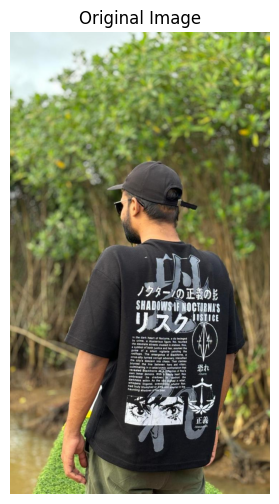

Step 2: Converting to grayscale and detecting edges...


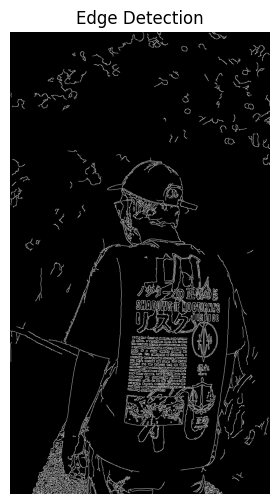

Step 3: Finding and filtering contours...


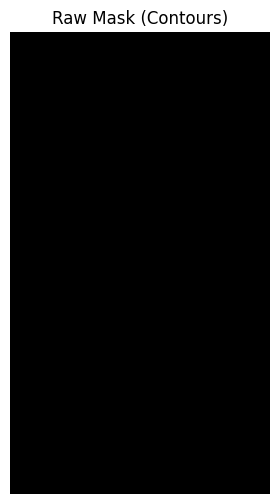

Step 4: Refining the mask...


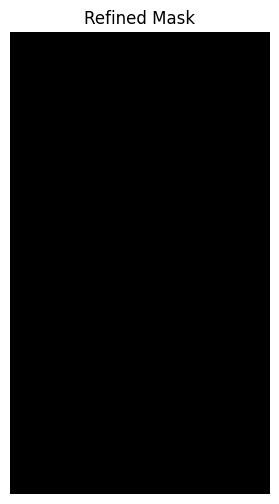

Step 5: Isolating the T-shirt region...


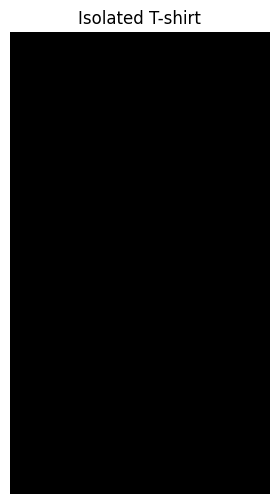

Step 6: Extracting non-black pixels from the isolated shirt region...
Extracted 921600 pixels for analysis.
Step 7: Performing KMeans clustering to find dominant colors...


/opt/anaconda3/envs/fashionCLIP-test/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Dominant Colors (RGB): [array([0, 0, 0], dtype=uint8), array([0, 0, 0], dtype=uint8), array([0, 0, 0], dtype=uint8)]
Proportions: [1.]
Step 8: Visualizing the dominant colors and their proportions...


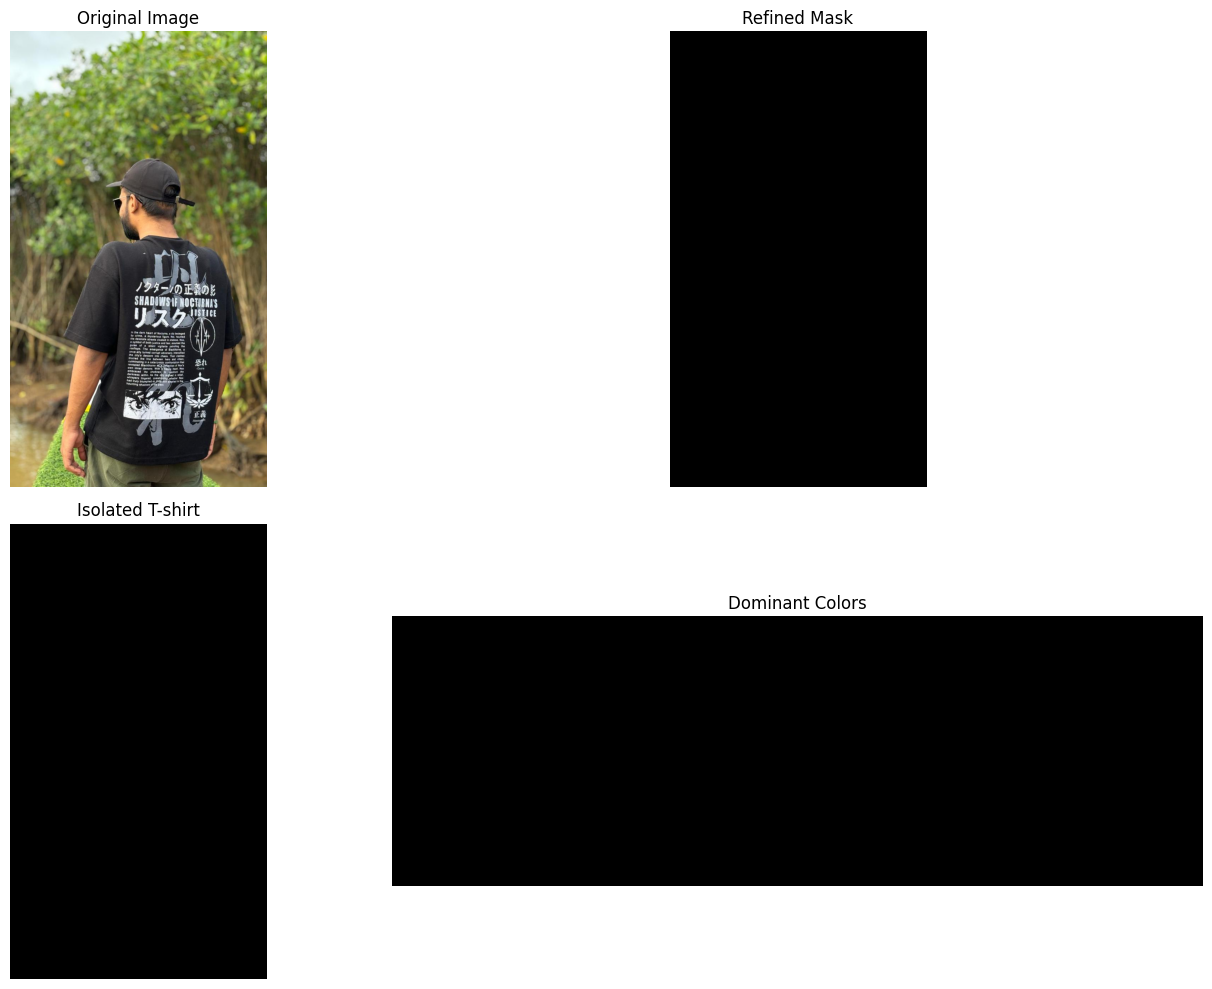

In [16]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def visualize_dominant_colors(colors, proportions):
    """
    Generate a bar chart showing the proportions of dominant colors.
    """
    bar = np.zeros((100, 300, 3), dtype='uint8')
    start_x = 0
    for i, (color, proportion) in enumerate(zip(colors, proportions)):
        end_x = start_x + int(proportion * bar.shape[1])
        bar[:, start_x:end_x] = color
        start_x = end_x
    return bar

def process_image_with_debugging(image_path):
    """
    Process the input image to isolate the T-shirt, extract its dominant colors, and visualize the results.
    """
    # Step 1: Load the image
    print("Step 1: Loading the image...")
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.title("Original Image")
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

    # Step 2: Convert to grayscale and perform edge detection
    print("Step 2: Converting to grayscale and detecting edges...")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    plt.figure(figsize=(10, 6))
    plt.title("Edge Detection")
    plt.imshow(edges, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 3: Find contours and filter based on size
    print("Step 3: Finding and filtering contours...")
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    for contour in contours:
        if 5000 < cv2.contourArea(contour) < 100000:  # Adjust the range based on the image size
            cv2.drawContours(mask, [contour], -1, (255), thickness=cv2.FILLED)

    plt.figure(figsize=(10, 6))
    plt.title("Raw Mask (Contours)")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 4: Refine the mask with morphological operations
    print("Step 4: Refining the mask...")
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    refined_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    plt.figure(figsize=(10, 6))
    plt.title("Refined Mask")
    plt.imshow(refined_mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 5: Apply the mask to the original image
    print("Step 5: Isolating the T-shirt region...")
    isolated_shirt = cv2.bitwise_and(image, image, mask=refined_mask)

    plt.figure(figsize=(10, 6))
    plt.title("Isolated T-shirt")
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Step 6: Extract non-black pixels
    print("Step 6: Extracting non-black pixels from the isolated shirt region...")
    hsv_image = cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2HSV)
    non_black_mask = cv2.inRange(isolated_shirt, (0, 0, 0), (255, 255, 255))
    isolated_pixels = hsv_image[non_black_mask > 0]

    # Debug: Check if we have enough pixels to proceed
    if len(isolated_pixels) == 0:
        print("Error: No significant pixels detected in the isolated shirt region. Check the mask or input image.")
        return

    print(f"Extracted {len(isolated_pixels)} pixels for analysis.")

    # Step 7: Use KMeans clustering to find dominant colors
    print("Step 7: Performing KMeans clustering to find dominant colors...")
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(isolated_pixels)
    dominant_colors = kmeans.cluster_centers_[:, :3]
    proportions = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    # Convert colors to RGB for visualization
    dominant_colors_rgb = [
        cv2.cvtColor(np.uint8([[color]]), cv2.COLOR_HSV2RGB)[0][0] for color in dominant_colors
    ]

    print("Dominant Colors (RGB):", dominant_colors_rgb)
    print("Proportions:", proportions)

    # Step 8: Visualize the results
    print("Step 8: Visualizing the dominant colors and their proportions...")
    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    # Refined mask
    plt.subplot(2, 2, 2)
    plt.imshow(refined_mask, cmap="gray")
    plt.title("Refined Mask")
    plt.axis("off")

    # Isolated shirt
    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.title("Isolated T-shirt")
    plt.axis("off")

    # Dominant colors as bar chart
    bar = visualize_dominant_colors(dominant_colors_rgb, proportions)
    plt.subplot(2, 2, 4)
    plt.imshow(bar)
    plt.title("Dominant Colors")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Provide the path to your image file
process_image_with_debugging("/Users/Tommy/Downloads/WhatsApp Image 2024-11-01 at 12.01.27.jpeg")


Step 1: Loading the image...


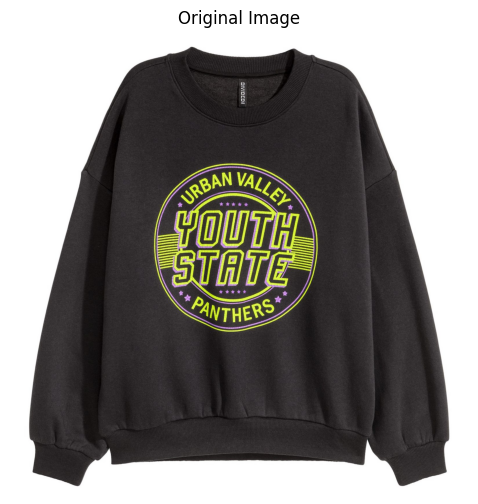

Step 2: Converting to grayscale and detecting edges...


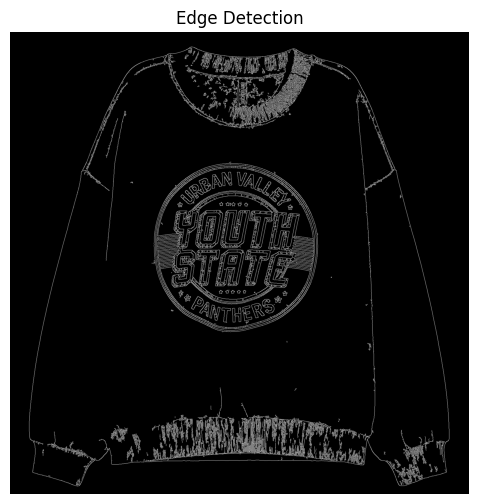

Step 3: Finding and filtering contours...


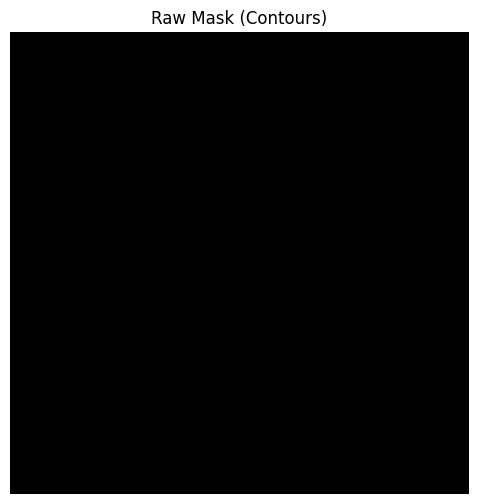

Step 4: Refining the mask...


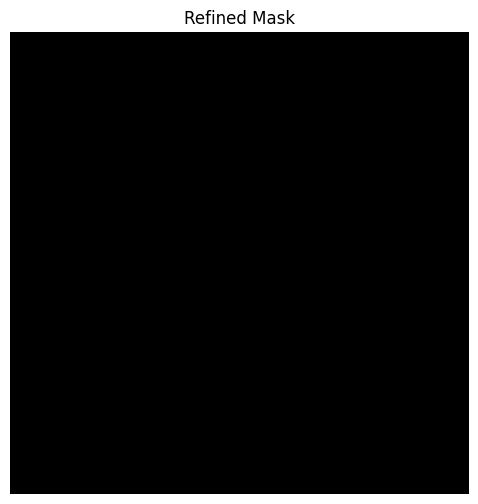

Step 5: Isolating the T-shirt region...


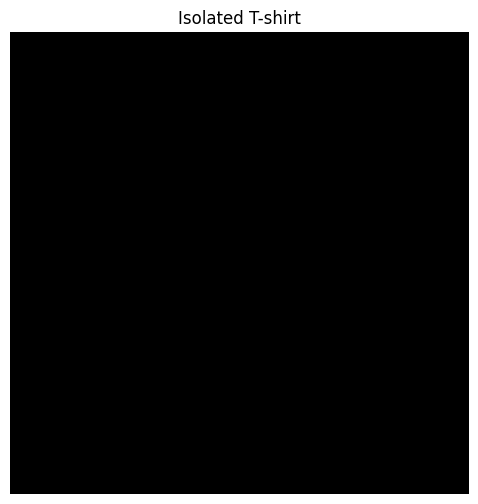

Step 6: Extracting black and white pixels from the T-shirt...
Extracted 2542400 pixels for analysis.
Step 7: Performing KMeans clustering to find dominant colors...


/opt/anaconda3/envs/fashionCLIP-test/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Dominant Colors (RGB): [array([0, 0, 0], dtype=uint8), array([0, 0, 0], dtype=uint8)]
Proportions: [1.]
Step 8: Visualizing the dominant colors and their proportions...


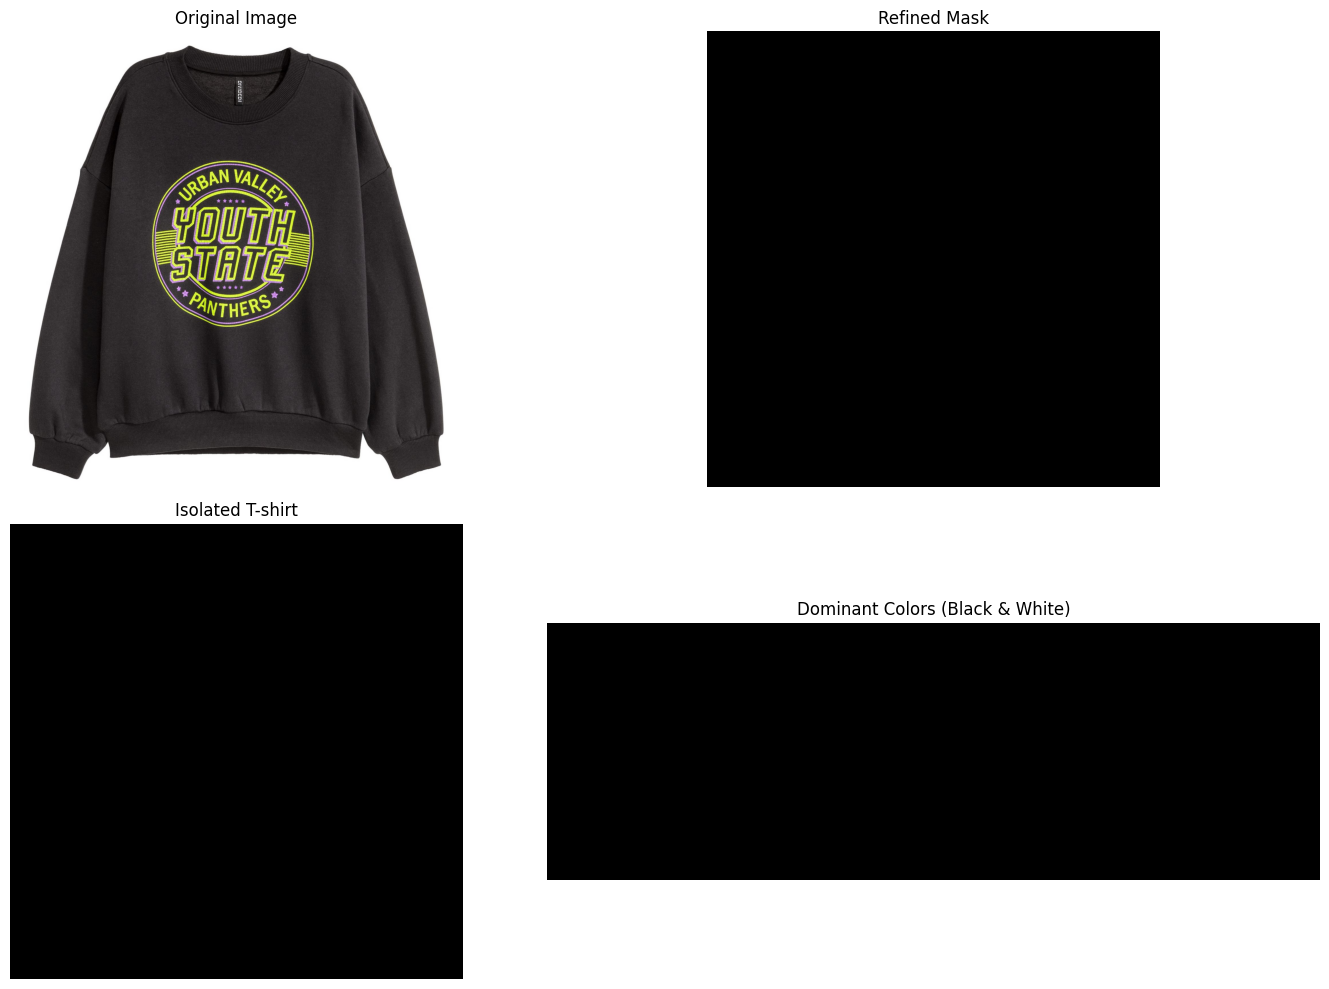

In [18]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def visualize_dominant_colors(colors, proportions):
    """
    Generate a bar chart showing the proportions of dominant colors.
    """
    bar = np.zeros((100, 300, 3), dtype='uint8')
    start_x = 0
    for i, (color, proportion) in enumerate(zip(colors, proportions)):
        end_x = start_x + int(proportion * bar.shape[1])
        bar[:, start_x:end_x] = color
        start_x = end_x
    return bar

def process_image_with_debugging(image_path):
    """
    Process the input image to isolate the T-shirt, extract its dominant colors (focus on black and white), and visualize the results.
    """
    # Step 1: Load the image
    print("Step 1: Loading the image...")
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.title("Original Image")
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

    # Step 2: Convert to grayscale and perform edge detection
    print("Step 2: Converting to grayscale and detecting edges...")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    plt.figure(figsize=(10, 6))
    plt.title("Edge Detection")
    plt.imshow(edges, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 3: Find contours and filter based on size
    print("Step 3: Finding and filtering contours...")
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    for contour in contours:
        if 10000 < cv2.contourArea(contour) < 200000:  # Adjust the range based on the T-shirt size
            cv2.drawContours(mask, [contour], -1, (255), thickness=cv2.FILLED)

    plt.figure(figsize=(10, 6))
    plt.title("Raw Mask (Contours)")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 4: Refine the mask with morphological operations
    print("Step 4: Refining the mask...")
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    refined_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    plt.figure(figsize=(10, 6))
    plt.title("Refined Mask")
    plt.imshow(refined_mask, cmap="gray")
    plt.axis("off")
    plt.show()

    # Step 5: Apply the mask to the original image
    print("Step 5: Isolating the T-shirt region...")
    isolated_shirt = cv2.bitwise_and(image, image, mask=refined_mask)

    plt.figure(figsize=(10, 6))
    plt.title("Isolated T-shirt")
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Step 6: Extract only black and white pixels
    print("Step 6: Extracting black and white pixels from the T-shirt...")
    hsv_image = cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2HSV)

    # Define HSV ranges for black and white
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 50])  # Adjusted for black
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 40, 255])  # Adjusted for white

    black_mask = cv2.inRange(hsv_image, lower_black, upper_black)
    white_mask = cv2.inRange(hsv_image, lower_white, upper_white)
    combined_mask = cv2.bitwise_or(black_mask, white_mask)

    isolated_pixels = hsv_image[combined_mask > 0]

    # Debug: Check if we have enough pixels to proceed
    if len(isolated_pixels) == 0:
        print("Error: No significant black or white pixels detected in the T-shirt region.")
        return

    print(f"Extracted {len(isolated_pixels)} pixels for analysis.")

    # Step 7: Use KMeans clustering to find dominant colors
    print("Step 7: Performing KMeans clustering to find dominant colors...")
    kmeans = KMeans(n_clusters=2, random_state=42)  # Focus on 2 dominant colors (black and white)
    kmeans.fit(isolated_pixels)
    dominant_colors = kmeans.cluster_centers_[:, :3]
    proportions = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    # Convert colors to RGB for visualization
    dominant_colors_rgb = [
        cv2.cvtColor(np.uint8([[color]]), cv2.COLOR_HSV2RGB)[0][0] for color in dominant_colors
    ]

    print("Dominant Colors (RGB):", dominant_colors_rgb)
    print("Proportions:", proportions)

    # Step 8: Visualize the results
    print("Step 8: Visualizing the dominant colors and their proportions...")
    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    # Refined mask
    plt.subplot(2, 2, 2)
    plt.imshow(refined_mask, cmap="gray")
    plt.title("Refined Mask")
    plt.axis("off")

    # Isolated shirt
    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(isolated_shirt, cv2.COLOR_BGR2RGB))
    plt.title("Isolated T-shirt")
    plt.axis("off")

    # Dominant colors as bar chart
    bar = visualize_dominant_colors(dominant_colors_rgb, proportions)
    plt.subplot(2, 2, 4)
    plt.imshow(bar)
    plt.title("Dominant Colors (Black & White)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Provide the path to your image file
process_image_with_debugging("/Users/Tommy/Downloads/WhatsApp Image 2024-11-07 at 01.02.41.jpeg")
